In [1]:
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

In [2]:
class DeepSphericalStitcher:
    def __init__(self, folder_path, resize_width=600):
        self.folder_path = folder_path
        self.resize_width = resize_width
        self.images = self._prepare_data()
        # Using SIFT for high-accuracy feature matching in a classroom environment
        self.finder = cv2.SIFT_create()

    def _prepare_data(self):
        """Loads images and normalizes lighting to fix dark areas."""
        files = sorted([f for f in os.listdir(self.folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        processed = []
        for f in files:
            img = cv2.imread(os.path.join(self.folder_path, f))
            if img is not None:
                h, w = img.shape[:2]
                img = cv2.resize(img, (self.resize_width, int(h * (self.resize_width/w))))

                # Apply CLAHE to equalize brightness across the 30 images
                lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
                l, a, b = cv2.split(lab)
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
                l = clahe.apply(l)
                img = cv2.merge((l, a, b))
                processed.append(cv2.cvtColor(img, cv2.COLOR_LAB2BGR))
        print(f"✅ Pre-processed {len(processed)} images for Spherical Stitching.")
        return processed

    def run_proper_stitch(self):
        """
        Uses the OpenCV Stitcher class configured for high-depth 360 panoramas.
        This handles Bundle Adjustment and Spherical Warping automatically.
        """
        # Create a Stitcher object specifically for PANORAMA mode
        # This mode uses Spherical Warping instead of Planar Warping
        stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)

        print("🚀 Starting Global Bundle Adjustment for 30 images...")
        # This is the 'Proper' way: it optimizes all 30 images simultaneously
        status, panorama = stitcher.stitch(self.images)

        if status == cv2.Stitcher_OK:
            # Post-process: Crop the wavy black edges
            final_result = self.auto_crop(panorama)
            print("✨ Stitching Successful!")
            cv2_imshow(final_result)
            cv2.imwrite('proper_360_stitch.jpg', final_result)
        else:
            print(f"❌ Stitching failed with Status Code: {status}")
            self._explain_error(status)

    def auto_crop(self, img):
        """Removes the irregular black borders created by spherical projection."""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)[1]
        cnts = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            return img[y:y+h, x:x+w]
        return img

    def _explain_error(self, status):
        errors = {
            1: "ERR_NEED_MORE_IMGS: Not enough overlap between your 30 images.",
            2: "ERR_HOMOGRAPHY_EST_FAIL: Could not find matching points (too dark or blurry).",
            3: "ERR_CAMERA_PARAMS_ADJUST_FAIL: Camera geometry mismatch."
        }
        print(errors.get(status, "Unknown error."))


✅ Pre-processed 30 images for Spherical Stitching.
🚀 Starting Global Bundle Adjustment for 30 images...
✨ Stitching Successful!


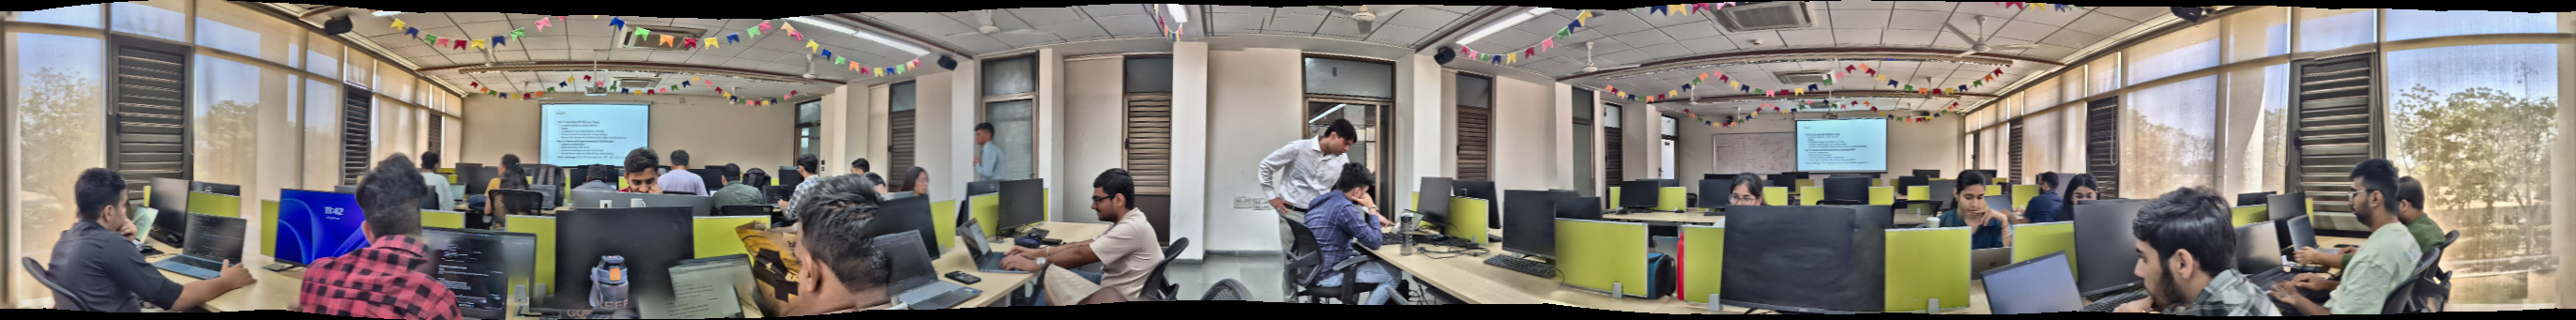

In [4]:
pipeline = DeepSphericalStitcher('/content/data')
pipeline.run_proper_stitch()